In [2]:
import pandas as pd
df = pd.read_csv('/content/sample_data/crop_yield_dataset.csv')

In [3]:
df = df[df['Crop_Yield'] > 0]

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
ts = df.groupby(df['Date'].dt.date)['Crop_Yield'].mean()
ts.index = pd.to_datetime(ts.index)

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

# Group by day → get daily average yield
daily_yield = df.groupby(df['Date'].dt.date)['Crop_Yield'].mean()

# Convert index back to datetime for time series
daily_yield.index = pd.to_datetime(daily_yield.index)

ts = daily_yield.sort_index()

print(ts.head())

Date
2014-01-01    52.962570
2014-01-02    49.481053
2014-01-03    31.582386
2014-01-04    35.247034
2014-01-05    32.578187
Name: Crop_Yield, dtype: float64


STATIONARY POINTS

In [6]:
#ADF Test
from statsmodels.tsa.stattools import adfuller

adf = adfuller(ts)

print("\n--- ADF TEST ---")
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])
print("Critical Values:")
for key, value in adf[4].items():
    print(f"   {key}: {value}")

if adf[1] < 0.05:
    print("Stationary")
else:
    print("Not Stationary")


--- ADF TEST ---
ADF Statistic: -7.148107107405433
p-value: 3.193310854138931e-10
Critical Values:
   1%: -3.4321632328202996
   5%: -2.862341184885642
   10%: -2.567196483328331
Stationary


In [7]:
#KPSS Test
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(ts, regression='c')

print("\n--- KPSS TEST ---")
print("KPSS Statistic:", kpss_test[0])
print("p-value:", kpss_test[1])
print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"   {key}: {value}")

if kpss_test[1] < 0.05:
    print("Not Stationary (Reject Null)")
else:
    print("Stationary")


--- KPSS TEST ---
KPSS Statistic: 0.043423677627070334
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739
Stationary


/tmp/ipython-input-2028887614.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(ts, regression='c')


<Figure size 1200x500 with 0 Axes>

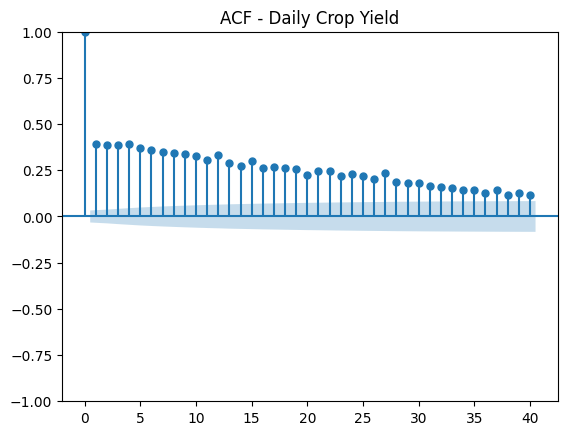

<Figure size 1200x500 with 0 Axes>

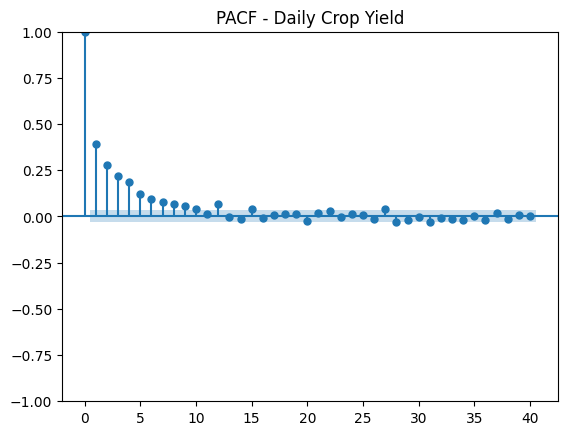

In [8]:
#ACF & PACF
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(ts, lags=40)
plt.title("ACF - Daily Crop Yield")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(ts, lags=40)
plt.title("PACF - Daily Crop Yield")
plt.show()

PROPHET MODEL

In [13]:
df = df.rename(columns={
    'Date': 'ds',
    'Yield': 'y'
})

df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')

print(df.head())

          ds Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  Wind_Speed  \
1 2014-01-01      Corn     Loamy     6.50    20.052576  79.947424    8.591577   
3 2014-01-01    Barley     Sandy     6.75    19.751848  80.000000    2.682683   
4 2014-01-01   Soybean     Peaty     5.50    16.110395  80.000000    7.696070   
5 2014-01-01    Cotton     Sandy     6.75    14.826739  80.000000   10.366657   
7 2014-01-01    Tomato      Clay     6.25    18.323272  80.000000    8.198084   

      N     P     K  Crop_Yield  Soil_Quality  
1  84.0  66.0  50.0  104.871310     66.666667  
3  50.0  40.0  30.0   58.939796     35.000000  
4  49.5  45.0  38.5   32.970413     22.166667  
5  55.0  44.0  36.0   29.356115     39.375000  
7  60.0  45.0  40.0   22.221375     42.291667  


In [9]:
!pip install prophet


In [11]:
from prophet import Prophet

In [10]:
!pip uninstall -y prophet fbprophet
!pip install prophet


Found existing installation: prophet 1.2.1
Uninstalling prophet-1.2.1:
  Successfully uninstalled prophet-1.2.1
  Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
Using cached prophet-1.2.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)


In [17]:
from prophet import Prophet
import pandas as pd

df = df.rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})
df['ds'] = pd.to_datetime(df['ds'])

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=30)  # Forecast next 30 days
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


             ds       yhat  yhat_lower  yhat_upper
3649 2024-01-26  37.446696    9.529537   64.000235
3650 2024-01-27  37.565961    9.248750   64.362112
3651 2024-01-28  37.148668    7.681602   66.058824
3652 2024-01-29  37.779453    9.741224   69.046907
3653 2024-01-30  37.822883    7.974137   65.676391


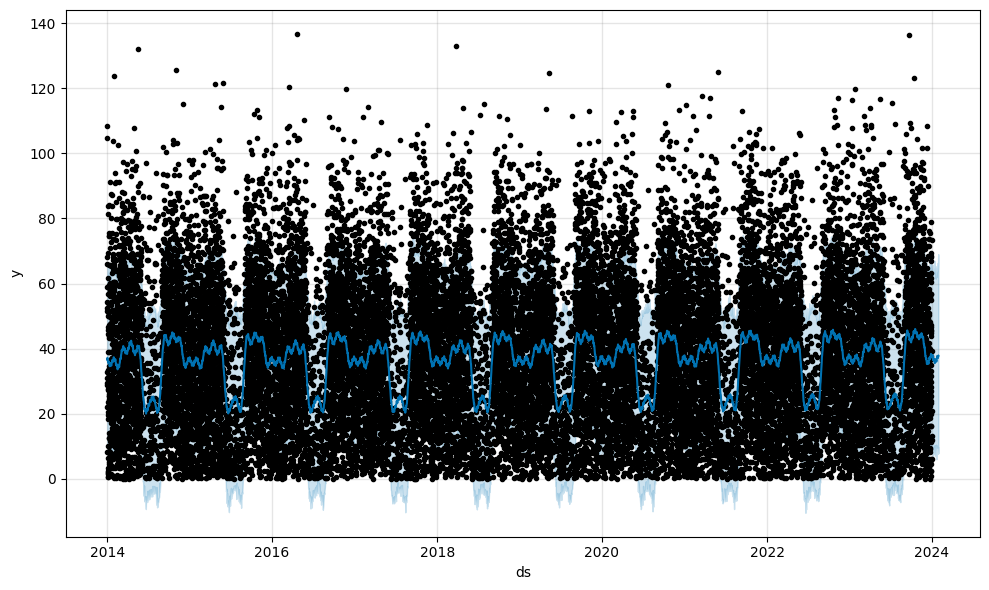

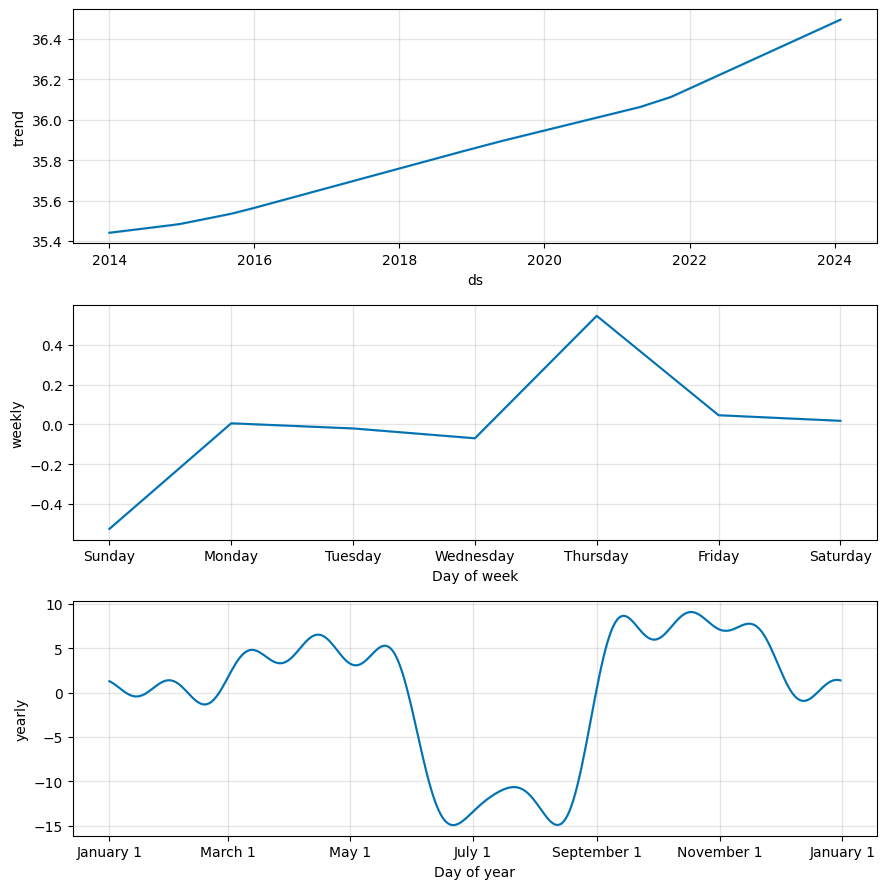

In [18]:
#Plot the Forecast
fig1 = model.plot(forecast)
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [19]:
#Explore the prophet model
import joblib
import matplotlib.pyplot as plt

joblib.dump(model, "prophet_model.pkl")
print("Model saved as prophet_model.pkl")

Model saved as prophet_model.pkl
